# Logistic Regression via Autograd 

In [1]:
from sklearn.datasets import load_breast_cancer
import torch

In [2]:
device  = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
# --- Utilitaire : courbe de perte train/val en direct ---
# Aucune installation nécessaire : matplotlib + IPython sont déjà dans le kernel.
import matplotlib.pyplot as plt
from IPython.display import clear_output


def live_plot_losses(history, title="Entraînement", xlabel="Epoch"):
    """Trace (et met à jour en direct) les courbes de perte train / val.

    history : dict de listes, p.ex. {"train_loss": [...], "val_loss": [...]}.
              Les clés "train_acc" / "val_acc" sont optionnelles et ajoutent
              un second panneau "accuracy".
    À appeler à la fin de chaque epoch : le graphe se redessine sur place,
    et la courbe finale reste affichée une fois l'entraînement terminé.
    """
    clear_output(wait=True)  # efface le graphe précédent -> effet "temps réel"
    has_acc = "train_acc" in history
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, ax = plt.subplots(1, 2 if has_acc else 1,
                           figsize=(12 if has_acc else 7, 4.5), squeeze=False)
    ax = ax[0]

    ax[0].plot(epochs, history["train_loss"], marker=".", label="Train")
    if history.get("val_loss"):
        ax[0].plot(epochs, history["val_loss"], marker=".", label="Val")
    ax[0].set(xlabel=xlabel, ylabel="Loss", title=f"{title} — Loss")
    ax[0].legend(); ax[0].grid(True, alpha=0.3)

    if has_acc:
        ax[1].plot(epochs, history["train_acc"], marker=".", label="Train")
        if history.get("val_acc"):
            ax[1].plot(epochs, history["val_acc"], marker=".", label="Val")
        ax[1].set(xlabel=xlabel, ylabel="Accuracy (%)", title=f"{title} — Accuracy")
        ax[1].legend(); ax[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

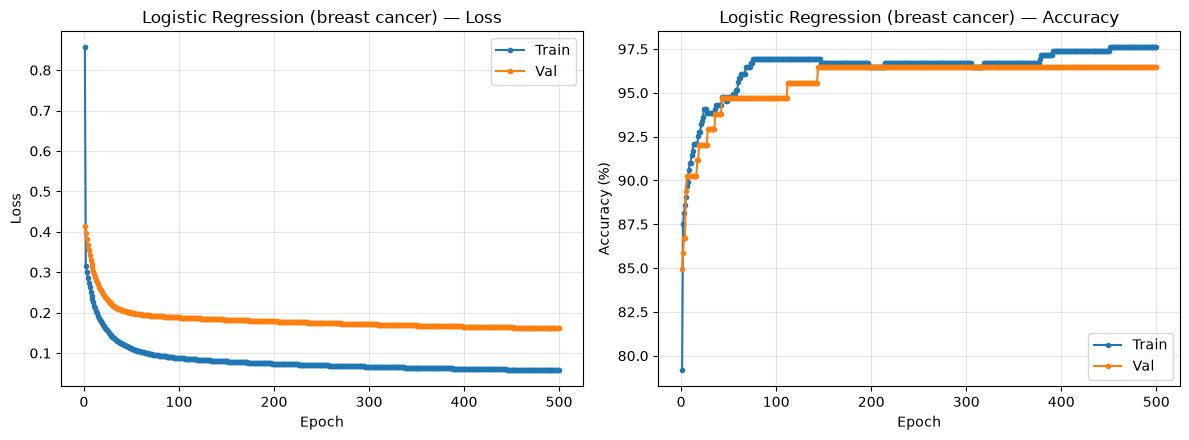

In [4]:
torch.manual_seed(0)

X, y = load_breast_cancer(as_frame=True, return_X_y=True)
X = torch.tensor(X.values, dtype=torch.float32, device=device)
y = torch.tensor(y.values, dtype=torch.float32, device=device)

# Standardisation (par feature)
X = (X - X.mean(dim=0)) / X.std(dim=0)

# --- Split train / validation (80 / 20) ---
m = X.shape[0]
idx = torch.randperm(m)
val_size = int(0.2 * m)
val_idx, train_idx = idx[:val_size], idx[val_size:]
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]

num_feats = X.shape[1]

w = torch.randn(num_feats, requires_grad = True, device=device)
b = torch.randn(1, requires_grad = True, device=device)

# Modèle de logistic regression
def  sigmoid(x):
    return 1 / (1 + torch.exp(-x))

def predict_proba(X, w, b):
    # Probabilité P(y=1 | x) = sigmoïde du logit z = X·w + b (sortie déjà dans [0, 1])
    return sigmoid(torch.matmul(X, w) + b)

# Optimiseur et loss
learning_rate = 1e-1
optimizer = torch.optim.SGD([w, b], lr=learning_rate)
criterion = torch.nn.BCELoss()

# Entraînement
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
n_epochs = 500
for epoch in range(1, n_epochs+1):
    # --- Apprentissage (full-batch) ---
    p = predict_proba(X_train, w, b)
    loss = criterion(p, y_train)

    # C'est ici que la magie opère -> Calcul du gradient automatique
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    # --- Métriques train / val ---
    with torch.no_grad():
        p_val = predict_proba(X_val, w, b)
        val_loss = criterion(p_val, y_val)
        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss.item())
        history["train_acc"].append(100 * ((p > 0.5).float() == y_train).float().mean().item())
        history["val_acc"].append(100 * ((p_val > 0.5).float() == y_val).float().mean().item())

    # Courbe en direct (redessinée toutes les 10 epochs pour rester fluide)
    if epoch % 10 == 0 or epoch == n_epochs:
        live_plot_losses(history, title="Logistic Regression (breast cancer)")

# Multi-Layer Perceptron

### Création de la classe MLP

In [5]:
import torch
from torch import nn


class MLP(torch.nn.Module):
    def __init__(self, in_shape, n_neurons, num_hiddens_layers, num_classes):
        super(MLP, self).__init__()
        self.input_layer = nn.Linear(in_shape, n_neurons)
        layers = []
        for _ in range(num_hiddens_layers):
            layers.append(nn.Linear(n_neurons, n_neurons))
            layers.append(nn.ReLU())
        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(n_neurons, num_classes, bias=False)

    def forward(self, x):
        # On renvoie les logits bruts : nn.CrossEntropyLoss applique lui-même le (log-)softmax.
        # Surtout NE PAS mettre de softmax ici, sinon il serait appliqué deux fois à l'entraînement.
        i = nn.ReLU()(self.input_layer(x))
        h = self.hidden_layers(i)
        y = self.output_layer(h)
        return y

    @torch.no_grad()
    def predict_proba(self, x):
        # Probabilités par classe (softmax) -> pour l'inférence uniquement, pas l'entraînement.
        return nn.Softmax(dim=1)(self.forward(x))


In [6]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

# Conversion immédiate en tenseurs torch -> on reste en full-torch pour la suite
X = torch.tensor(X, dtype=torch.float32)          # (70000, 784), pixels 0..255
y = torch.tensor(y.astype("int64"), dtype=torch.long)

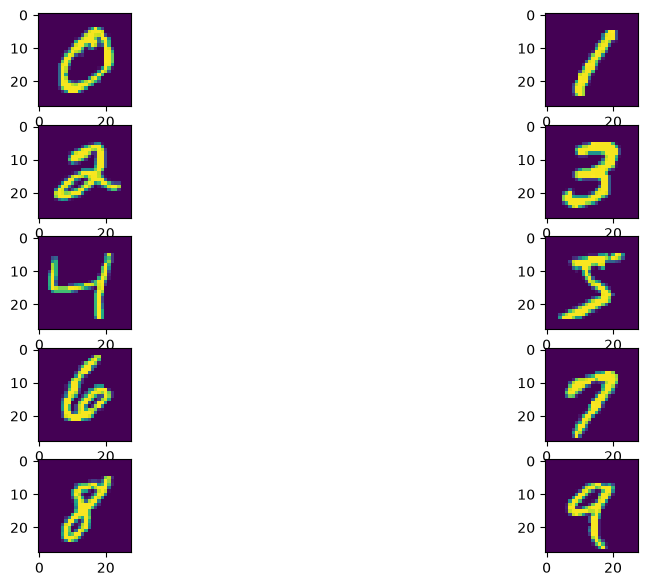

In [7]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(5, 2)

fig.set_size_inches(12,7)
axs = axs.ravel()

for i in range(10):
    # premier indice où l'étiquette vaut i (argmax sur un masque booléen)
    first = (y == i).int().argmax()
    axs[i].imshow(X[first].reshape(28, 28))

In [8]:
mnist_classifier = MLP(in_shape=X.shape[1], 
                       n_neurons=256, num_hiddens_layers=3, num_classes=10)

In [9]:
sum(p.numel() for p in mnist_classifier.parameters())

400896

In [10]:
from torch.utils.data import Dataset, DataLoader

class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.to(torch.float32) / 255.   # normalisation des pixels dans [0, 1]
        self.y = y.to(torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Retourne une paire (image, label)
        return self.X[idx], self.y[idx]

In [11]:
m = X.shape[0]

idx_shuffle =torch.randperm(m)

X_train = X[idx_shuffle[:50000]]
X_val = X[idx_shuffle[50000:]]
y_train = y[idx_shuffle[:50000]]
y_val = y[idx_shuffle[50000:]]

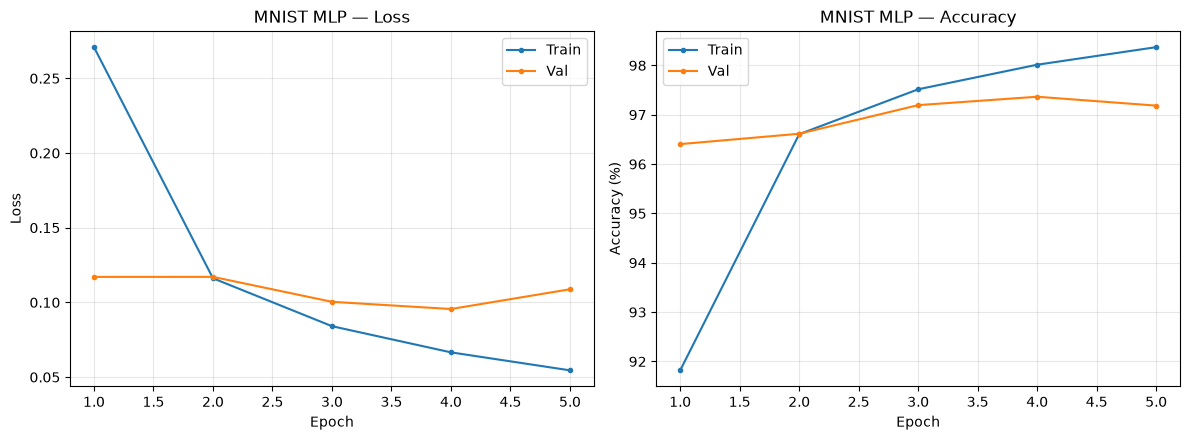

In [12]:
# Optimiseur et loss
learning_rate = 1e-3
optimizer = torch.optim.Adam(mnist_classifier.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

batch_size = 32
train_dataset = MNISTDataset(X_train, y_train)
val_dataset = MNISTDataset(X_val, y_val)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Entraînement
mnist_classifier = mnist_classifier.to(device)
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
n_epochs = 5
first = True
for epoch in range(1, n_epochs+1):
    total_train_loss = 0
    total_val_loss = 0
    correct_train = 0
    correct_val = 0
    total_train = 0
    total_val = 0
    
    # --- Apprentissage ---
    mnist_classifier.train()
    for xb, yb in train_dataloader:
        xb = xb.to(device)
        yb = yb.to(device)
        # Forward pass
        y_pred = mnist_classifier(xb)

        # Loss
        loss = criterion(y_pred, yb)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if first:
            print(mnist_classifier.hidden_layers[0].weight.grad)  # Affichage du gradient
            first = False
        
        # Accumulation des pertes
        total_train_loss += loss.item() * xb.size(0)

        # Accuracy
        preds = torch.argmax(y_pred, dim=1)
        correct_train += (preds == yb).sum().item()
        total_train += yb.size(0)

    epoch_loss_train = total_train_loss / total_train
    epoch_acc_train = 100 * correct_train / total_train

    # --- Validation ---
    mnist_classifier.eval()
    with torch.no_grad():
        for xb, yb in val_dataloader:
            xb = xb.to(device)
            yb = yb.to(device)
            y_pred = mnist_classifier(xb)
            loss = criterion(y_pred, yb)

            total_val_loss += loss.item() * xb.size(0)

            preds = torch.argmax(y_pred, dim=1)
            correct_val += (preds == yb).sum().item()
            total_val += yb.size(0)

    epoch_loss_val = total_val_loss / total_val
    epoch_acc_val = 100 * correct_val / total_val

    # Historique + courbe train/val en direct (remplace le print par epoch)
    history["train_loss"].append(epoch_loss_train)
    history["val_loss"].append(epoch_loss_val)
    history["train_acc"].append(epoch_acc_train)
    history["val_acc"].append(epoch_acc_val)
    live_plot_losses(history, title="MNIST MLP")

Text(0.5, 1.0, 'Prediction=2')

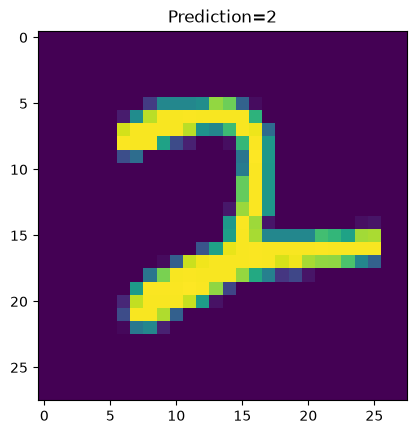

In [13]:
idx = torch.randint(0, m, (1,)).item()

x = X[idx].view(1, -1).to(device).to(torch.float) / 255.
pred_class = mnist_classifier.predict_proba(x).argmax(dim=1).item()

plt.imshow(X[idx].reshape(28, 28))
plt.title(f'Prediction={pred_class}')

In [14]:
sum(p.numel() for p in mnist_classifier.parameters())

400896

# Exercice 
Réécrire la première cellule avec la logique PyTorch.

Cela nécessite de :
* Créer un dataset et un dataloader
* Créer un modèle LogisticRegression en héritant de torch.nn.Module

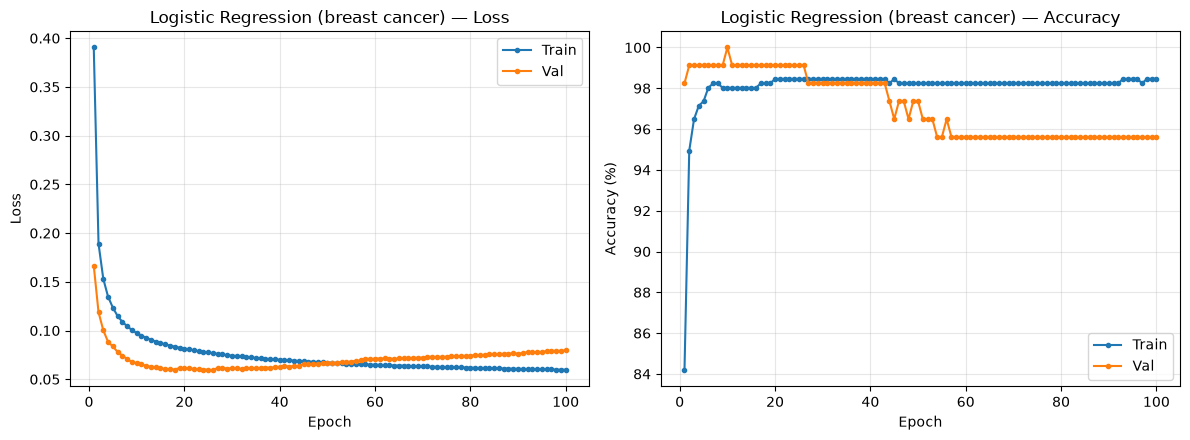

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.datasets import load_breast_cancer

# --- 0. Configuration du device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)

# --- 1. Charger et préparer les données (Sur CPU par défaut) ---
X_raw, y_raw = load_breast_cancer(as_frame=True, return_X_y=True)
X_tensor = torch.tensor(X_raw.values, dtype=torch.float32)
y_tensor = torch.tensor(y_raw.values, dtype=torch.float32).unsqueeze(1)  # (N, 1) pour BCELoss

# Standardisation (sur CPU)
X_tensor = (X_tensor - X_tensor.mean(dim=0)) / X_tensor.std(dim=0)


# --- 2. Créer un Dataset personnalisé ---
class BreastCancerDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

full_dataset = BreastCancerDataset(X_tensor, y_tensor)

# Split Train / Val (80% / 20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)


# --- 3. Définition du Modèle ---
# La régression logistique = UNE seule couche linéaire suivie d'une sigmoïde.
# (C'est exactement ce que faisaient w, b + sigmoid dans la 1re cellule, mais
#  encapsulé dans un torch.nn.Module.)
class LogisticRegression(torch.nn.Module):
    def __init__(self, in_shape):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(in_shape, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))  # sortie dans [0, 1] -> P(y=1 | x)

# Instanciation et envoi sur le device
model = LogisticRegression(X_tensor.shape[1]).to(device)


# --- 4. Définir loss et optimiseur ---
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)


# --- 5. Entraînement ---
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
n_epochs = 100 # Le modèle converge très vite
for epoch in range(1, n_epochs + 1):
    model.train() # Mode entraînement activé
    total_train_loss = 0
    correct_train = 0
    total_train = 0
    for batch_X, batch_y in train_dataloader:
        # Envoi des mini-batchs sur le GPU/CPU au fil de l'eau
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # Forward pass
        outputs = model(batch_X)

        # Calcul de la loss
        loss = criterion(outputs, batch_y)

        # Backprop (L'ordre standard et propre : zero_grad -> backward -> step)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * batch_X.size(0)
        correct_train += ((outputs > 0.5) == batch_y).sum().item()
        total_train += batch_y.size(0)

    # --- Évaluation sur l'ensemble de Validation ---
    model.eval() # Mode évaluation activé (désactive dropout/batchnorm si présents)
    total_val_loss = 0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for batch_X, batch_y in val_dataloader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            preds = model(batch_X)
            loss = criterion(preds, batch_y)

            total_val_loss += loss.item() * batch_X.size(0)
            correct_val += ((preds > 0.5) == batch_y).sum().item()
            total_val += batch_y.size(0)

    # Historique + courbe train/val en direct (remplace le print d'accuracy)
    history["train_loss"].append(total_train_loss / total_train)
    history["val_loss"].append(total_val_loss / total_val)
    history["train_acc"].append(100 * correct_train / total_train)
    history["val_acc"].append(100 * correct_val / total_val)
    if epoch % 5 == 0 or epoch == n_epochs:
        live_plot_losses(history, title="Logistic Regression (breast cancer)")

## MLP sur california housing dataset

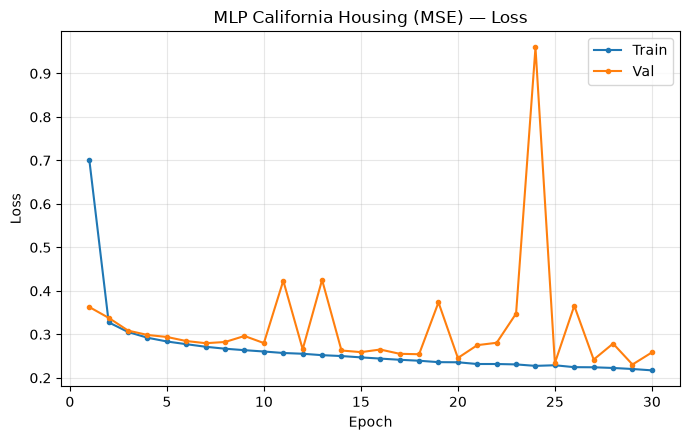

Val RMSE finale = 0.508 (soit 50.8k$)


In [16]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn

# --- 0. Configuration ---
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Chargement et Nettoyage des Données ---
data_path = "../datasets/housing/housing.csv"
data = pd.read_csv(data_path)
data = data.loc[data['housing_median_age'] < 52]
data = data.loc[data['median_house_value'] < 499999]
data = data.dropna()

x_numeric_columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                     'total_bedrooms', 'population', 'households', 'median_income']

# Conversion explicite des booléens de get_dummies en float pour éviter les conflits
x_ocean_proximity_one_hot = pd.get_dummies(data["ocean_proximity"]).astype(float)

# Colonnes numériques : on les standardise (moyenne 0, écart-type 1)
X_num = torch.tensor(data[x_numeric_columns].values, dtype=torch.float32)
X_num = (X_num - X_num.mean(dim=0)) / X_num.std(dim=0)

# Colonnes one-hot : on NE les standardise PAS, elles doivent rester en 0/1
X_onehot = torch.tensor(x_ocean_proximity_one_hot.values, dtype=torch.float32)

# Création de X en float32 (Type standard de PyTorch)
X = torch.hstack([X_num, X_onehot])

# y est directement mis au format (N, 1) en float32
y = torch.tensor(data['median_house_value'].values, dtype=torch.float32).unsqueeze(1) / 1e5  # $ -> 100k$


# --- 2. Créer un Dataset personnalisé ---
class HousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

full_dataset = HousingDataset(X, y)

# Split Train / Val (80% / 20%) pour une évaluation saine
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)


# --- 3. Définition du Modèle (MLP) ---
class MLP(torch.nn.Module):
    def __init__(self, in_shape, n_neurons, num_hiddens_layers):
        super(MLP, self).__init__()
        self.input_layer = nn.Linear(in_shape, n_neurons)
        layers = []
        for _ in range(num_hiddens_layers):
            layers.append(nn.Linear(n_neurons, n_neurons))
            layers.append(nn.ReLU())
        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(n_neurons, 1, bias=False)

    def forward(self, x):
        i = nn.ReLU()(self.input_layer(x))
        h = self.hidden_layers(i)
        y = self.output_layer(h) # Pas d'activation finale pour de la régression linéaire/continue
        return y

model = MLP(X.shape[1], 64, 4).to(device)


# --- 4. Définir loss et optimiseur ---
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


# --- 5. Entraînement ---
history = {"train_loss": [], "val_loss": []}
n_epochs = 30
for epoch in range(1, n_epochs + 1):
    model.train()
    total_train_loss = 0
    total_train = 0
    for batch_X, batch_y in train_dataloader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Forward pass
        outputs = model(batch_X)

        # Calcul de la loss (batch_y est déjà en (N, 1) grâce au unsqueeze du début)
        loss = criterion(outputs, batch_y)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * batch_X.size(0)
        total_train += batch_X.size(0)

    # --- Évaluation (MSE) sur la Validation ---
    model.eval()
    total_val_loss = 0
    total_val = 0
    with torch.no_grad():
        for batch_X, batch_y in val_dataloader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            preds = model(batch_X)
            total_val_loss += criterion(preds, batch_y).item() * batch_X.size(0)
            total_val += batch_X.size(0)

    # Historique + courbe train/val (MSE) en direct
    history["train_loss"].append(total_train_loss / total_train)
    history["val_loss"].append(total_val_loss / total_val)
    live_plot_losses(history, title="MLP California Housing (MSE)")

# RMSE finale en 100k$ pour l'interprétation (val_loss est une MSE)
final_rmse = history["val_loss"][-1] ** 0.5
print(f'Val RMSE finale = {final_rmse:.3f} (soit {final_rmse * 100:.1f}k$)')

### Exercice bonus — Régulariser le MLP (Dropout) + *LR scheduler*
Reprenez votre classe `MLP` et l'entraînement sur California Housing / MNIST, puis :
1. ajoutez une couche `nn.Dropout(p=0.2)` entre deux couches cachées ;
2. ajoutez un planificateur de learning rate `CosineAnnealingLR` ;
3. comparez les courbes train/val avec et sans ces ajouts.

_Squelette de solution ci-dessous (nécessite PyTorch + les cellules précédentes exécutées)._


In [17]:
# import torch, torch.nn as nn
# class MLPReg(nn.Module):
#     def __init__(self, d_in, d_hidden=64, p_drop=0.2):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(d_in, d_hidden), nn.ReLU(),
#             nn.Dropout(p_drop),                 # <-- regularisation
#             nn.Linear(d_hidden, d_hidden), nn.ReLU(),
#             nn.Dropout(p_drop),
#             nn.Linear(d_hidden, 1))
#     def forward(self, x): return self.net(x)
#
# model = MLPReg(d_in=X_train.shape[1])
# opt = torch.optim.Adam(model.parameters(), lr=1e-3)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
# for epoch in range(EPOCHS):
#     model.train()
#     ...  # forward / loss / backward / opt.step()
#     scheduler.step()                          # <-- on fait avancer le LR
#     # IMPORTANT : model.eval() avant l'evaluation pour desactiver le Dropout
print('Exercice bonus : voir le squelette ci-dessus. Comparez val_loss avec/sans Dropout.')


Exercice bonus : voir le squelette ci-dessus. Comparez val_loss avec/sans Dropout.
